## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Understanding Dataset

In [2]:
df = pd.read_csv('C:\\Users\\M.LAPTOP\\Desktop\\data_science_portfolio\\data\\Sample - Superstore.csv', encoding='latin-1')
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

## Missing Values

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Feature Engineering

### Date Features

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

Order Date and Ship Date were converted into datetime format to enable extraction of time-based features and calculation of shipping time for better analysis

In [9]:
df['shipping_time'] = (df['Ship Date'] - df['Order Date']).dt.days
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'shipping_time'],
      dtype='str')

**Shipping Time was created** using Ship Date and Order Date **to analyze whether delayed deliveries impact profitability**.

In [10]:
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Day of Week'] = df['Order Date'].dt.dayofweek
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'shipping_time', 'Order Month', 'Order Year', 'Day of Week'],
      dtype='str')

### Business Features

In [11]:
df['Discount_amount'] = df['Sales'] * df['Discount']
df['Profit_margin'] = df['Profit'] / df['Sales']
df['price_per_unit'] = df['Sales'] / df['Quantity']
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'shipping_time', 'Order Month', 'Order Year', 'Day of Week',
       'Discount_amount', 'Profit_margin', 'price_per_unit'],
      dtype='str')

In [12]:
df.sample(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,shipping_time,Order Month,Order Year,Day of Week,Discount_amount,Profit_margin,price_per_unit
5674,5675,CA-2016-146318,2016-01-22,2016-01-27,Standard Class,MC-17275,Marc Crier,Consumer,United States,Seattle,...,2,0.0,6.2208,5,1,2016,4,0.0000,0.480,6.480
4035,4036,US-2016-108777,2016-12-12,2016-12-12,Same Day,JM-15655,Jim Mitchum,Corporate,United States,Lorain,...,6,0.2,76.7904,0,12,2016,0,76.7904,0.200,63.992
4622,4623,CA-2017-147228,2017-09-09,2017-09-14,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Columbia,...,3,0.2,-1.9872,5,9,2017,5,1.7664,-0.225,2.944


### Sales

In this analysis, I will use the year feature to study yearly sales trends and understand how sales have changed over time.

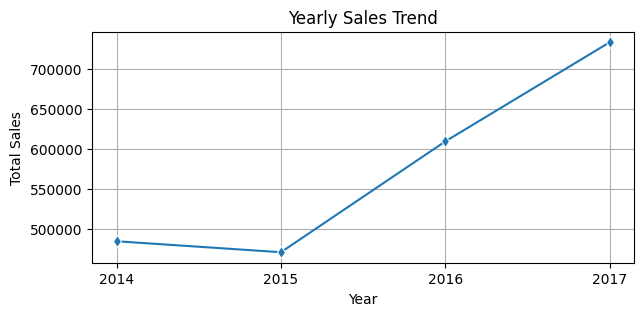

In [13]:

yearly_sales = df.groupby('Order Year')['Sales'].sum().reset_index()
plt.figure(figsize=(7, 3))
sns.lineplot(data=yearly_sales, x='Order Year', y='Sales', marker='d')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(yearly_sales['Order Year'])
plt.grid()
plt.show()


This steady growth indicates a positive business trajectory and suggests that **customer demand is expanding over time**.

now **we will examine monthly sales**. This will help in understanding sales trends and seasonal patterns in the data.

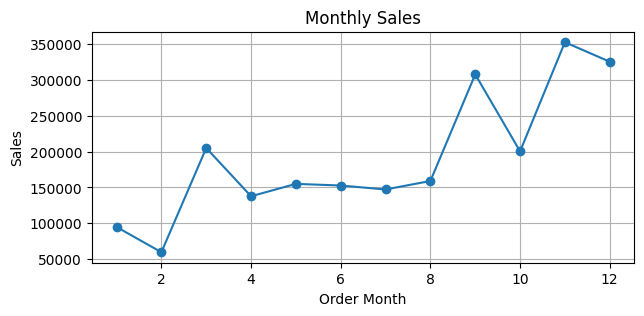

Highest Sales Month: 11, Sales: 352461.071
Lowest Sales Month: 2, Sales: 59751.2514


In [14]:
monthly_sales = df.groupby('Order Month')['Sales'].sum()
monthly_sales.plot(kind='line' ,figsize=(7, 3),grid=True, marker='o')
plt.title('Monthly Sales')
plt.xlabel('Order Month')
plt.ylabel('Sales')
plt.show()

print(f"Highest Sales Month: {monthly_sales.idxmax()}, Sales: {monthly_sales.max()}")
print(f"Lowest Sales Month: {monthly_sales.idxmin()}, Sales: {monthly_sales.min()}")

The analysis shows that sales reach their peak in 11th month, **November**

#### Category-wise Sales trend

Sales across different product categories to understand their performance and contribution to overall sales.

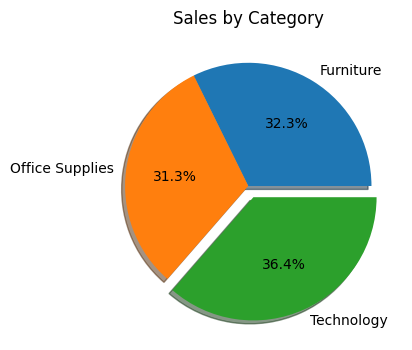

Highest Sales Category: Technology, Sales: 836154.033
Lowest Sales Category: Office Supplies, Sales: 719047.032


In [15]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales.plot(kind='pie' ,figsize=(8, 4),explode=[0.0, 0.0, 0.1], autopct='%1.1f%%' ,shadow=True)
plt.title('Sales by Category')  

plt.show()
print(f"Highest Sales Category: {category_sales.idxmax()}, Sales: {category_sales.max()}")
print(f"Lowest Sales Category: {category_sales.idxmin()}, Sales: {category_sales.min()}")

#### Sub-Category Sales

In [16]:
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum()
highest_sales_sub_category = sub_category_sales.idxmax()
lowest_sales_sub_category = sub_category_sales.idxmin()
print(f"Highest Sales Sub-Category: {highest_sales_sub_category}, Sales: {sub_category_sales[highest_sales_sub_category]}")
print(f"Lowest Sales Sub-Category: {lowest_sales_sub_category}, Sales: {sub_category_sales[lowest_sales_sub_category]}")

Highest Sales Sub-Category: Phones, Sales: 330007.054
Lowest Sales Sub-Category: Fasteners, Sales: 3024.28


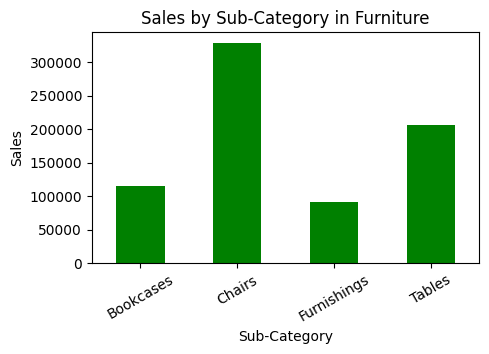

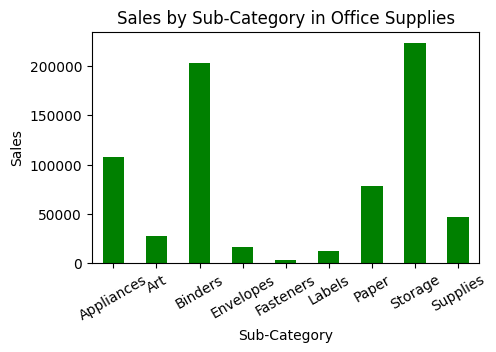

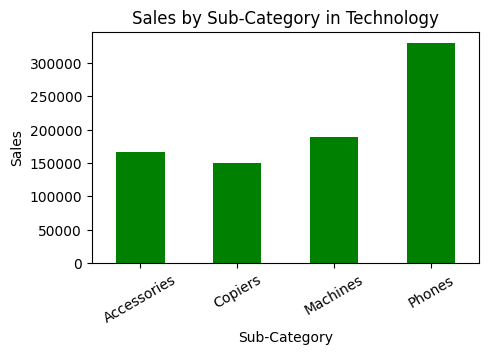

In [17]:
categories = df['Category'].unique()
for category in categories:
    category_data = df[df['Category'] == category]
    sub_category_sales = category_data.groupby('Sub-Category')['Sales'].sum()
    sub_category_sales.plot(kind='bar', figsize=(5, 3),color='green')
    plt.title(f'Sales by Sub-Category in {category}')
    plt.ylabel('Sales')
    plt.xticks(rotation=30)
    plt.show()  

Identifying these high and low performing sub-categories can help in making better decisions, such as focusing on top-performing products and improving or promoting the weaker ones.

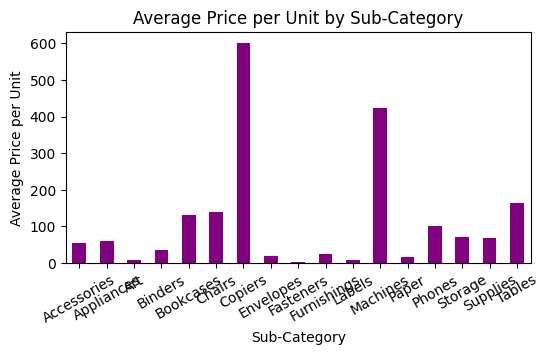

In [18]:
average_price_per_unit = df.groupby('Sub-Category')['price_per_unit'].mean()
average_price_per_unit.plot(kind='bar', figsize=(6, 3), color='purple')
plt.title('Average Price per Unit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Average Price per Unit')
plt.xticks(rotation=30)
plt.show()

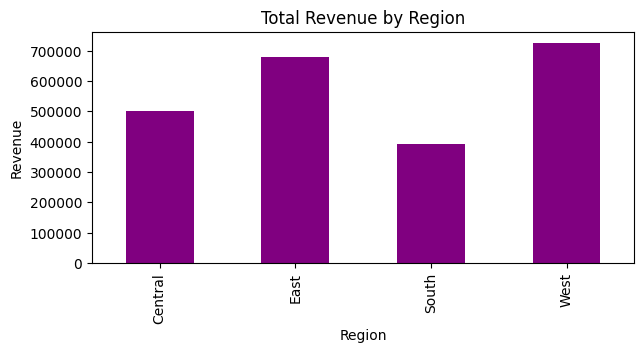

In [19]:
revenue_by_region = df.groupby('Region')['Sales'].sum() 
revenue_by_region.plot(kind='bar', figsize=(7, 3), color='purple')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.show()

#### Top 10 products by Sales

In [20]:
top_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Sales:")  
print(top_sales)

Top 10 Products by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64



Sales Volume by Sub-Category:


C:\Users\M.LAPTOP\AppData\Local\Temp\ipykernel_13184\3471834455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_category_sales_volume.index, y=sub_category_sales_volume.values, palette='viridis')


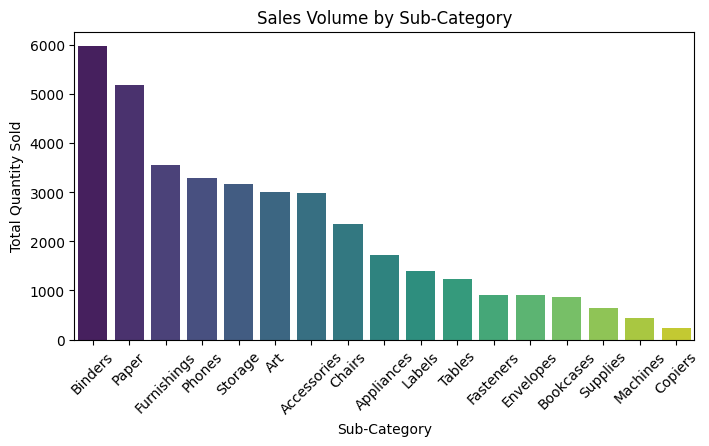

In [21]:
sub_category_sales_volume = df.groupby('Sub-Category')['Quantity'].sum().sort_values(ascending=False)
print("\nSales Volume by Sub-Category:")    
plt.figure(figsize=(8, 4))
sns.barplot(x=sub_category_sales_volume.index, y=sub_category_sales_volume.values, palette='viridis')
plt.title('Sales Volume by Sub-Category')   
plt.xlabel('Sub-Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.show()


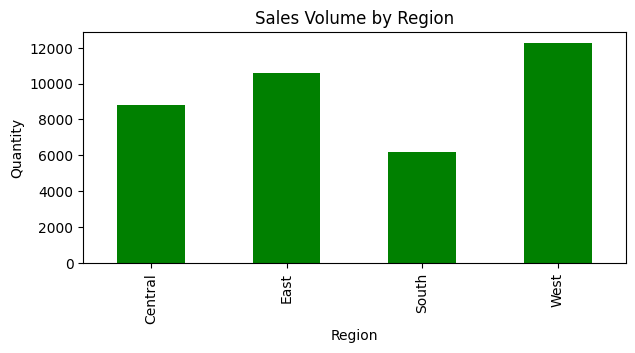

In [22]:
sales_volume_by_region = df.groupby('Region')['Quantity'].sum()
sales_volume_by_region.plot(kind='bar', figsize=(7, 3), color='green')
plt.title('Sales Volume by Region')
plt.xlabel('Region')
plt.ylabel('Quantity')
plt.show()

### Profit 

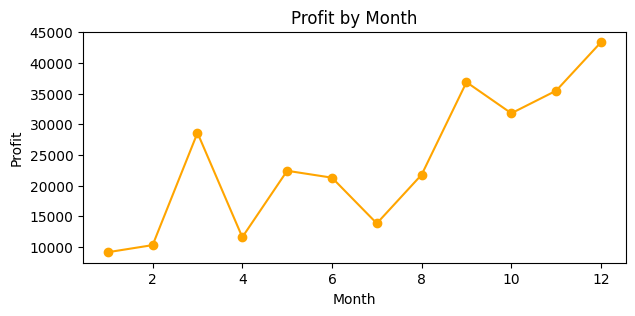

Highest Profit Month: 12, Profit: 43369.1919
Lowest Profit Month: 1, Profit: 9134.4461


In [23]:
monthly_profit = df.groupby('Order Month')['Profit'].sum()
monthly_profit.plot(kind='line', figsize=(7, 3),color='orange',marker='o')
plt.title('Profit by Month') 
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()
print(f"Highest Profit Month: {monthly_profit.idxmax()}, Profit: {monthly_profit.max()}")
print(f"Lowest Profit Month: {monthly_profit.idxmin()}, Profit: {monthly_profit.min()}")

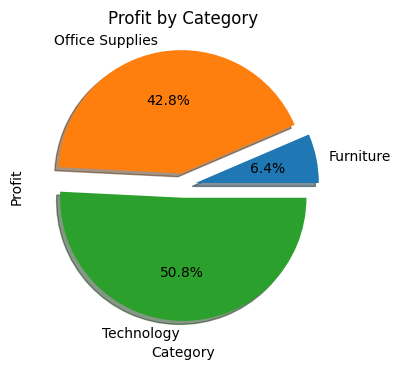

In [24]:
profit_by_category = df.groupby('Category')['Profit'].sum()
profit_by_category.plot(kind='pie', figsize=(8, 4),color='orange',explode=[0.1, 0.1, 0.1], autopct='%1.1f%%', shadow=True)
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show() 

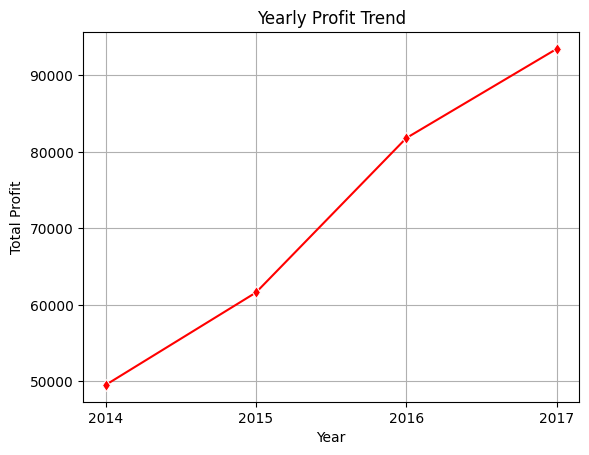

In [25]:
yearly_profit = df.groupby('Order Year')['Profit'].sum().reset_index()
sns.lineplot(data=yearly_profit, x='Order Year', y='Profit', marker='d', color='red')
plt.title('Yearly Profit Trend')
plt.xlabel('Year')
plt.ylabel('Total Profit')
plt.xticks(yearly_profit['Order Year'])
plt.grid()
plt.show()

C:\Users\M.LAPTOP\AppData\Local\Temp\ipykernel_13184\734103443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_sub_category.index, y=profit_by_sub_category.values, palette='viridis')


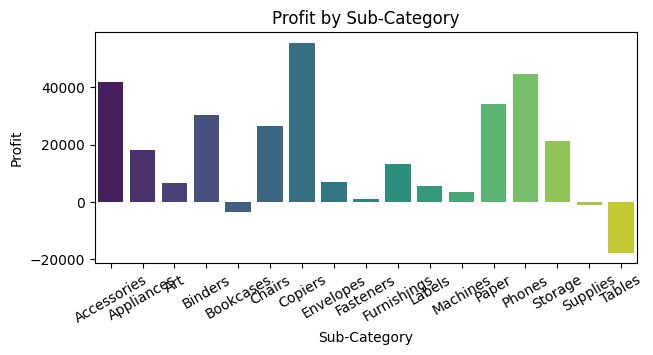


Profit by Sub-Category:
Sub-Category
Accessories    41936.6357
Appliances     18138.0054
Art             6527.7870
Binders        30221.7633
Bookcases      -3472.5560
Chairs         26590.1663
Copiers        55617.8249
Envelopes       6964.1767
Fasteners        949.5182
Furnishings    13059.1436
Labels          5546.2540
Machines        3384.7569
Paper          34053.5693
Phones         44515.7306
Storage        21278.8264
Supplies       -1189.0995
Tables        -17725.4811
Name: Profit, dtype: float64


In [26]:
profit_by_sub_category = df.groupby('Sub-Category')['Profit'].sum()
plt.figure(figsize=(7, 3))
sns.barplot(x=profit_by_sub_category.index, y=profit_by_sub_category.values, palette='viridis')
plt.title('Profit by Sub-Category')     
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=30)
plt.show()

print("\nProfit by Sub-Category:")
print(profit_by_sub_category)

**A category with high sales may not necessarily have the highest profit.**

In [27]:
top_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Profit:")   
print(top_profit)

Top 10 Products by Profit:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


In [28]:
avg_profit_per_product = df.groupby('Product Name')['Profit'].mean().sort_values(ascending=False).head(10)
print("Top 10 Products by Average Profit:") 
print(avg_profit_per_product)

Top 10 Products by Average Profit:
Product Name
Canon imageCLASS 2200 Advanced Copier                                    5039.985600
Canon imageCLASS MF7460 Monochrome Digital Laser Multifunction Copier    1995.990000
Ativa V4110MDD Micro-Cut Shredder                                        1886.473050
3D Systems Cube Printer, 2nd Generation, Magenta                         1858.985700
Zebra ZM400 Thermal Label Printer                                        1671.768000
Hewlett-Packard Desktjet 6988DT Refurbished Printer                      1668.205000
Hewlett-Packard Deskjet 3050a All-in-One Color Inkjet Printer            1459.200000
HP Designjet T520 Inkjet Large Format Printer - 24" Color                1364.992200
Canon PC1060 Personal Laser Copier                                       1142.733675
Ibico EPK-21 Electric Binding System                                     1115.094100
Name: Profit, dtype: float64


#### Loss

In the profit analysis, **I noticed some negative values, which indicate losses**. To understand this, I will further explore the reasons behind it, such as high discounts or low profit margins, in order to identify the root cause and improve profitability.

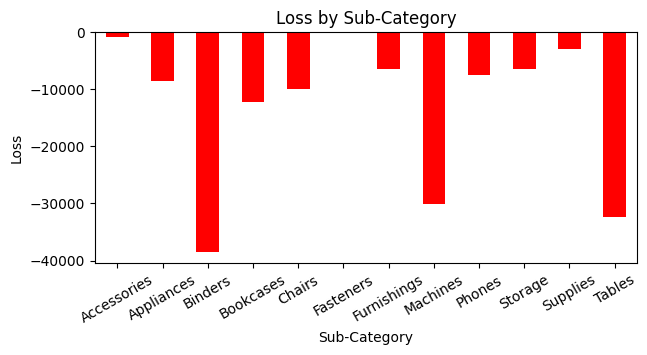

In [29]:
loss = df[df['Profit'] < 0]
loss_by_category = loss.groupby('Sub-Category')['Profit'].sum()
loss_by_category.plot(kind='bar', figsize=(7, 3),color='red')
plt.title('Loss by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Loss')
plt.xticks(rotation=30)
plt.show()


In [30]:
loss_data = df[df['Profit'] < 0].sort_values(by='Profit')
loss_data.groupby('Sub-Category')['Profit'].sum().sort_values()

Sub-Category
Binders       -38510.4964
Tables        -32412.1483
Machines      -30118.6682
Bookcases     -12152.2060
Chairs         -9880.8413
Appliances     -8629.6412
Phones         -7530.6235
Furnishings    -6490.9134
Storage        -6426.3038
Supplies       -3015.6219
Accessories     -930.6265
Fasteners        -33.1952
Name: Profit, dtype: float64

#### Sales to Profit Ratio

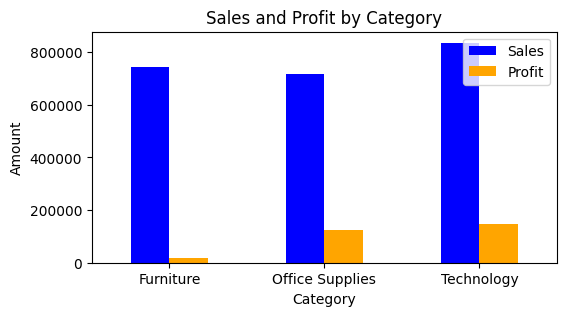

In [31]:
profit_sales_by_category = df.groupby('Category')[['Sales', 'Profit']].sum()
profit_sales_by_category.plot(kind='bar', figsize=(6, 3), color=['blue', 'orange'])
plt.title('Sales and Profit by Category')   
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.legend(['Sales', 'Profit'])
plt.show()



C:\Users\M.LAPTOP\AppData\Local\Temp\ipykernel_13184\582426310.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sub-Category', y='Sales to Profit Ratio', data=df, palette='viridis')


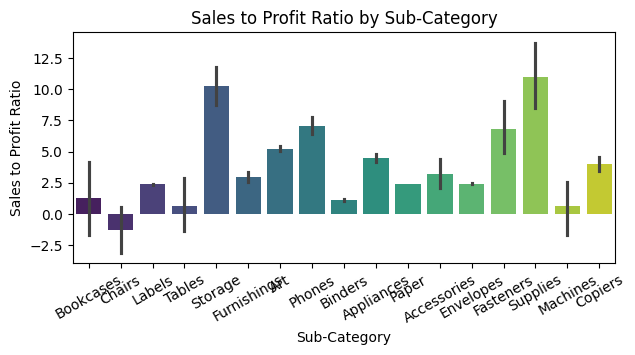

In [32]:
df['Sales to Profit Ratio'] = df['Sales'] / df['Profit']
plt.figure(figsize=(7, 3))
sns.barplot(x='Sub-Category', y='Sales to Profit Ratio', data=df, palette='viridis')
plt.title('Sales to Profit Ratio by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Sales to Profit Ratio')
plt.xticks(rotation=30)
plt.show()   

Having highest sales to profit ratio means:
costs are too high,
You’re giving too many discounts,
pricing is weak.

### Customer 

In [33]:
top_customers = df['Customer ID'].value_counts().head(10)

print("Top 10 Customers by Order Count:")
print(top_customers)


Top 10 Customers by Order Count:
Customer ID
WB-21850    37
MA-17560    34
JL-15835    34
PP-18955    34
JD-15895    32
CK-12205    32
SV-20365    32
EH-13765    32
EP-13915    31
ZC-21910    31
Name: count, dtype: int64


In [34]:
customer_spent = df.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Customers by Total Spent:")   
print(customer_spent)

Top 10 Customers by Total Spent:
Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
Name: Sales, dtype: float64


In [35]:
avg_discount_by_customer = df.groupby('Customer ID')['Discount'].mean().sort_values(ascending=False).head(10)
print("Top 10 Customers by Average Discount Taken:")    
print(avg_discount_by_customer)

Top 10 Customers by Average Discount Taken:
Customer ID
TS-21085    0.700000
RH-19555    0.533333
VS-21820    0.475000
LH-17020    0.466667
GH-14485    0.466667
TP-21415    0.462000
AG-10765    0.460000
MG-18205    0.450000
CD-11980    0.433333
SG-20890    0.400000
Name: Discount, dtype: float64


#### High Profit Regions

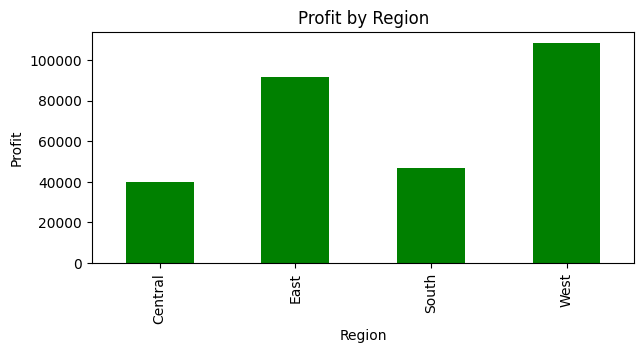

In [36]:
profit_by_region = df.groupby('Region')['Profit'].sum() 
profit_by_region.plot(kind='bar', figsize=(7, 3),color='green')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()


### Droping Useless Cols

In [37]:
data = df.drop(columns=[
    'Row ID', 'Order ID', 'Customer Name', 'Product Name'
])
data.columns

Index(['Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment',
       'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID',
       'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit',
       'shipping_time', 'Order Month', 'Order Year', 'Day of Week',
       'Discount_amount', 'Profit_margin', 'price_per_unit',
       'Sales to Profit Ratio'],
      dtype='str')

In [38]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(data.median(numeric_only=True), inplace=True)


,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,...,Discount,Profit,shipping_time,Order Month,Order Year,Day of Week,Discount_amount,Profit_margin,price_per_unit,Sales to Profit Ratio
0,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,...,0.00,41.9136,3,11,2016,1,0.000000,0.1600,130.9800,6.250000
1,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,...,0.00,219.5820,3,11,2016,1,0.000000,0.3000,243.9800,3.333333
2,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,90036,West,...,0.00,6.8714,4,6,2016,6,0.000000,0.4700,7.3100,2.127660
3,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,...,0.45,-383.0310,7,10,2015,6,430.909875,-0.4000,191.5155,-2.500000
4,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,...,0.20,2.5164,7,10,2015,6,4.473600,0.1125,11.1840,8.888889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,2014-01-21,2014-01-23,Second Class,TB-21400,Consumer,United States,Miami,Florida,33180,South,...,0.20,4.1028,2,1,2014,1,5.049600,0.1625,8.4160,6.153846
9990,2017-02-26,2017-03-03,Standard Class,DB-13060,Consumer,United States,Costa Mesa,California,92627,West,...,0.00,15.6332,5,2,2017,6,0.000000,0.1700,45.9800,5.882353
9991,2017-02-26,2017-03-03,Standard Class,DB-13060,Consumer,United States,Costa Mesa,California,92627,West,...,0.20,19.3932,5,2,2017,6,51.715200,0.0750,129.2880,13.333333
9992,2017-02-26,2017-03-03,Standard Class,DB-13060,Consumer,United States,Costa Mesa,California,92627,West,...,0.00,13.3200,5,2,2017,6,0.000000,0.4500,7.4000,2.222222


In [39]:
import numpy as np

num_df = data.select_dtypes(include=[np.number])

np.isinf(num_df).sum().sum()

np.int64(0)

## Model 1 : Random Forest Regressor

### Predict Profit

### Target

In [40]:
num_cols = [
    'Sales', 'Quantity', 'Discount', 'shipping_time',
    'Discount_amount', 'Profit_margin',
    'price_per_unit', 'Sales to Profit Ratio'
]

In [41]:
cat_cols = [
    'Ship Mode', 'Segment', 'Region',
    'Category', 'Sub-Category'
]

In [42]:
X = data[num_cols + cat_cols]
y_reg = data['Profit']

data['is_loss'] = (data['Profit'] < 0).astype(int)
y_clf = data['is_loss']

In [43]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = data[num_cols + cat_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

reg_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 10.413947385692845
R2 Score: 0.2192910324084123


## Model 2: Random Forest Classifier

### Predict Loss

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)

clf_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

clf_model.fit(X_train, y_train)

y_pred = clf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1636
           1       1.00      1.00      1.00       363

    accuracy                           1.00      1999
   macro avg       1.00      1.00      1.00      1999
weighted avg       1.00      1.00      1.00      1999



In [46]:
import pandas as pd

feature_names = reg_model.named_steps['preprocessing'].get_feature_names_out()

importances = reg_model.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

                       Feature  Importance
0                   num__Sales    0.611728
4         num__Discount_amount    0.151336
5           num__Profit_margin    0.128829
6          num__price_per_unit    0.025295
2                num__Discount    0.023297
7   num__Sales to Profit Ratio    0.019969
3           num__shipping_time    0.013464
13      cat__Segment_Corporate    0.005772
33  cat__Sub-Category_Machines    0.003789
16            cat__Region_East    0.002304


We developed two machine learning models: **a regression model to predict profit and a classification model to identify loss-making transactions**. The analysis revealed that profitability is not directly proportional to sales, as several high-sales transactions resulted in negative profit due to factors such as high discounts and cost inefficiencies.


## Models Evaluation

In [47]:
new_data = {
    'Sales': [500],
    'Quantity': [2],
    'Discount': [0.2],
    'shipping_time': [3],
    'Discount_amount': [100],
    'Profit_margin': [0.1],
    'price_per_unit': [250],
    'Sales to Profit Ratio': [5],
    'Ship Mode': ['Second Class'],
    'Segment': ['Consumer'],
    'Region': ['West'],
    'Category': ['Technology'],
    'Sub-Category': ['Phones']
}

import pandas as pd
new_df = pd.DataFrame(new_data)

In [48]:
profit_pred = reg_model.predict(new_df)
print("Predicted Profit:", profit_pred[0])

Predicted Profit: 62.30071499999996


In [49]:
loss_pred = clf_model.predict(new_df)
print("Loss Prediction (1=Loss, 0=Profit):", loss_pred[0])

Loss Prediction (1=Loss, 0=Profit): 0
